# Experimental Framework — Vietnamese CV–JD Weakly Supervised LTR

**Audit:** [`docs/RESEARCH_AUDIT.md`](../docs/RESEARCH_AUDIT.md) · **Đề cương:** [`DE_CUONG_CHOT.md`](../DE_CUONG_CHOT.md)

## 01. Research Hypothesis

**Claim được phép**

> Learning-based ranking functions can outperform manually designed weighted matching scores under weak supervision (no hiring outcomes).

**Không claim:** trọng số tối ưu toàn cục · dự đoán hired/rejected · production ranking · LF/gold = ground truth · RankNet MLP = “học trọng số”.

**Giả thuyết vận hành**

| Bước | Giả thuyết kiểm chứng | Model |
|---|---|---|
| 1 | Learned linear weights cải thiện gold ranking vs trọng số tay | H → B1 |
| 2 | Soft weak labels hữu ích hơn / khác hard heuristic labels | B1 → B2 |
| 3 | Pairwise RankNet cải thiện vs pointwise | B2 → M1 (RQ1) |
| 4 | Skill-gap phụ cải thiện QualSens và/hoặc NDCG | M1 → M2 (RQ2) |

Hai RQ **độc lập**. M2 ↑ NDCG nhưng QualSens không ↑ → *chỉ* kết luận cải thiện ranking metric, chưa chứng minh robustness năng lực.


## 02. Experimental Assumptions (sau audit)

1. **Cùng feature space:** train subsample và gold dùng **cùng** adapter TF–IDF cache (`prepare_feature_space`). Không BGE/BERT/BM25.
2. **Weak labels phụ thuộc feature:** LF = ngưỡng trên cùng `x` → `y_prob` không độc lập với đầu vào. Đánh giá khóa = gold độc lập.
3. **B1 target lệch H:** `heuristic_label = 1[H≥0.45]`. B1 chỉ ablation learned weighting.
4. **Model selection không đụng gold:** early-stop / HP theo **val pair-loss** `L_rank`.
5. **B2 = soft BCEWithLogits** trên `y_prob` — không Ridge MSE.
6. **Gold:** *graded evaluation set* 0–3 (`relevance`); một annotator; không gọi GT; ~12 JD → power thấp.
7. **CI chính:** seed-level paired delta (5 seeds). Job-bootstrap trong 1 seed chỉ là diagnostic.
8. **Seed kép:** cùng `seed` vừa shuffle JD split vừa init trọng số / pair sample trong grid HP → within-seed HP fair; across-seed đo đồng thời split+init variance.
9. **Kết luận:** CI 95% chứa 0 → không kết luận cải thiện chắc chắn.
10. **Val pairs:** `build_rank_pairs_robust` hạ margin đến 0; nếu vẫn rỗng thì fail-fast — không tune/early-stop trên train.


## Environment & Imports


In [1]:
from __future__ import annotations

import os, sys, json, time, warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.linear_model import LogisticRegression
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.data.loader import FEATURE_COLS, RealKaggleDatasetAdapter
from src.weak import WeakLabelPipeline
from src.weak.pipeline import LF_COLS
from src.models.pairing import build_rank_pairs, build_rank_pairs_robust
from src.models.skill_gap import SkillGapHead, build_gap_targets, skill_gap_loss
from src.eval.metrics import ndcg_at_k, map_at_k, paired_bootstrap_test
from src.eval.perturbation import qualify_sensitivity

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")
print("ROOT", ROOT)
print("FEATURE_COLS", FEATURE_COLS)
print("Device note: cudnn deterministic flags only apply when CUDA is available.")


ROOT /home/mytam/EDA-insights/paper-2026
FEATURE_COLS ['loc_match', 'skill_iou', 'exp_score', 'role_match', 'desc_sem_sim']
Device note: cudnn deterministic flags only apply when CUDA is available.


## Configuration (paper mode)


In [2]:
@dataclass
class ExpConfig:
    seeds: tuple = (42, 52, 62, 72, 82)
    train_ratio: float = 0.80
    val_ratio: float = 0.15
    feature_cols: tuple = tuple(FEATURE_COLS)
    n_jobs_sample: int = 80
    n_cands_sample: int = 120
    df_threshold: float = 0.15
    lf_pos_percentile: float = 75.0
    lf_neg_percentile: float = 25.0
    aggregator: str = "dawid_skene"
    pair_margin: float = 0.02
    max_pairs_per_job: int = 150
    hidden1: int = 32
    hidden2: int = 16
    dropout: float = 0.1
    max_epochs: int = 100
    patience: int = 10
    lr_grid: tuple = (1e-2, 1e-3, 1e-4)
    batch_grid: tuple = (16, 32, 64)
    default_lr: float = 1e-3
    default_batch: int = 32
    lambda_gap_grid: tuple = (0.05, 0.1, 0.2, 0.4)
    default_lambda_gap: float = 0.2
    k_list: tuple = (5, 10)
    n_bootstrap: int = 1000
    gold_path: str = "data/gold/human_validated_benchmark_graded_0_3.csv"
    gold_rel_col: str = "relevance"
    out_dir: str = "reports/phase4a"
    fig_dir: str = "reports/phase4a/figures"
    smoke: bool = False  # MUST stay False to lock paper numbers

CFG = ExpConfig()
if CFG.smoke:
    CFG = ExpConfig(seeds=(42,), lr_grid=(1e-3,), batch_grid=(32,),
                    lambda_gap_grid=(0.2,), max_epochs=20, n_bootstrap=200, smoke=True)
else:
    print("PAPER MODE | seeds", CFG.seeds, "| gold", CFG.gold_path)

OUT_DIR = ROOT / CFG.out_dir
FIG_DIR = ROOT / CFG.fig_dir
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int) -> np.random.RandomState:
    import random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    return np.random.RandomState(seed)

print(json.dumps(asdict(CFG), indent=2, default=list))


PAPER MODE | seeds (42, 52, 62, 72, 82) | gold data/gold/human_validated_benchmark_graded_0_3.csv
{
  "seeds": [
    42,
    52,
    62,
    72,
    82
  ],
  "train_ratio": 0.8,
  "val_ratio": 0.15,
  "feature_cols": [
    "loc_match",
    "skill_iou",
    "exp_score",
    "role_match",
    "desc_sem_sim"
  ],
  "n_jobs_sample": 80,
  "n_cands_sample": 120,
  "df_threshold": 0.15,
  "lf_pos_percentile": 75.0,
  "lf_neg_percentile": 25.0,
  "aggregator": "dawid_skene",
  "pair_margin": 0.02,
  "max_pairs_per_job": 150,
  "hidden1": 32,
  "hidden2": 16,
  "dropout": 0.1,
  "max_epochs": 100,
  "patience": 10,
  "lr_grid": [
    0.01,
    0.001,
    0.0001
  ],
  "batch_grid": [
    16,
    32,
    64
  ],
  "default_lr": 0.001,
  "default_batch": 32,
  "lambda_gap_grid": [
    0.05,
    0.1,
    0.2,
    0.4
  ],
  "default_lambda_gap": 0.2,
  "k_list": [
    5,
    10
  ],
  "n_bootstrap": 1000,
  "gold_path": "data/gold/human_validated_benchmark_graded_0_3.csv",
  "gold_rel_col": "rel

## 03. Dataset Audit

Kiểm tra trước train: quy mô, missing, trùng cặp. Subsample Kaggle seed=42 (`n_jobs_sample`×`n_cands_sample`, 70 CV/JD).


In [3]:
ADAPTER = RealKaggleDatasetAdapter(
    data_dir=str(ROOT / "data"),
    random_seed=42,
    df_threshold=CFG.df_threshold,
)
df_raw = ADAPTER.load_and_preprocess(
    n_jobs=CFG.n_jobs_sample,
    n_candidates=CFG.n_cands_sample,
)
CAND_COL = "cand_id" if "cand_id" in df_raw.columns else "user_id"
assert all(c in df_raw.columns for c in FEATURE_COLS)

audit = {
    "n_pairs": int(len(df_raw)),
    "n_jobs": int(df_raw["job_id"].nunique()),
    "n_cands": int(df_raw[CAND_COL].nunique()),
    "pairs_per_job_mean": float(df_raw.groupby("job_id").size().mean()),
    "pairs_per_job_min": int(df_raw.groupby("job_id").size().min()),
    "pairs_per_job_max": int(df_raw.groupby("job_id").size().max()),
    "dup_pair_keys": int(df_raw.duplicated(["job_id", CAND_COL]).sum()),
    "nan_features": {c: int(df_raw[c].isna().sum()) for c in FEATURE_COLS},
    "heuristic_pos_rate": float(df_raw["heuristic_label"].mean()),
    "has_skill_text_cols": bool({"job_skills", "user_skills"} <= set(df_raw.columns)),
}
print(json.dumps(audit, indent=2, ensure_ascii=False))
display(df_raw[list(FEATURE_COLS)].describe().T[["min", "mean", "max"]])
display(df_raw[list(FEATURE_COLS)].corr().round(3))
assert audit["dup_pair_keys"] == 0
assert sum(audit["nan_features"].values()) == 0


[DATA LOADER] Loaded global DF. Filtering 41 skills with DF > 0.15
Loading real Kaggle dataset from '/home/mytam/EDA-insights/paper-2026/data'...
Constructed 5600 real candidate-job matching evaluation pairs.
{
  "n_pairs": 5600,
  "n_jobs": 80,
  "n_cands": 120,
  "pairs_per_job_mean": 70.0,
  "pairs_per_job_min": 70,
  "pairs_per_job_max": 70,
  "dup_pair_keys": 0,
  "nan_features": {
    "loc_match": 0,
    "skill_iou": 0,
    "exp_score": 0,
    "role_match": 0,
    "desc_sem_sim": 0
  },
  "heuristic_pos_rate": 0.23125,
  "has_skill_text_cols": true
}


,min,mean,max
loc_match,0.000000,0.244107,1.000000
skill_iou,0.000000,0.017350,0.178571
exp_score,0.201897,0.968296,1.000000
role_match,0.000000,0.052401,1.000000
desc_sem_sim,0.000000,0.181000,0.638157


,loc_match,skill_iou,exp_score,role_match,desc_sem_sim
loc_match,1.000,-0.001,-0.006,0.001,-0.015
skill_iou,-0.001,1.000,-0.006,0.054,0.373
exp_score,-0.006,-0.006,1.000,0.051,0.101
role_match,0.001,0.054,0.051,1.000,0.092
desc_sem_sim,-0.015,0.373,0.101,0.092,1.000


## 04. Leakage Check

Cấm: cùng JD train/val/test; gold JD trong train; fit LF trên gold/test; dùng gold để tune.

Cho phép: cùng ứng viên (`cand_id`) ở nhiều split (job-disjoint). **Không claim** generalization sang CV hoàn toàn mới — limitation §17.


In [4]:
def job_disjoint_split(df, seed, holdout_jobs, train_ratio=0.80, val_ratio=0.10):
    rng = np.random.RandomState(seed)
    jobs = np.array(sorted(set(df["job_id"].unique()) - set(holdout_jobs)))
    rng.shuffle(jobs)
    n = len(jobs)
    n_train = max(1, int(train_ratio * n))
    n_val = max(1, int(val_ratio * n))
    train_jobs, val_jobs = jobs[:n_train], jobs[n_train:n_train + n_val]
    test_jobs = jobs[n_train + n_val:]
    if len(test_jobs) == 0:
        test_jobs = train_jobs[-1:]; train_jobs = train_jobs[:-1]
    s_tr, s_va, s_te = set(train_jobs), set(val_jobs), set(test_jobs)
    hold = set(holdout_jobs)
    assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te)
    assert hold.isdisjoint(s_tr | s_va | s_te)
    return (
        df[df["job_id"].isin(train_jobs)].copy(),
        df[df["job_id"].isin(val_jobs)].copy(),
        df[df["job_id"].isin(test_jobs)].copy(),
        {"train_jobs": sorted(s_tr), "val_jobs": sorted(s_va), "test_jobs": sorted(s_te)},
    )

print("job_disjoint_split ready")


job_disjoint_split ready


## 05. Gold Evaluation Loader + Shared Feature Space

*Graded evaluation set* 0–3. Feature gold tính bằng **cùng** `ADAPTER` đã fit TF–IDF cho `df_raw` (không fit lại vectorizer riêng).

Assertion: trên cặp overlap với subsample 70 CV/JD, `|Δfeature| < 1e-6`.


In [5]:
gold = pd.read_csv(ROOT / CFG.gold_path)
assert CFG.gold_rel_col in gold.columns
if CAND_COL not in gold.columns:
    alt = "cand_id" if CAND_COL == "user_id" else "user_id"
    gold = gold.rename(columns={alt: CAND_COL})
GOLD_JOBS = sorted(gold["job_id"].unique().tolist())
print("Gold pairs", len(gold), "| jobs", len(GOLD_JOBS))
print(gold[CFG.gold_rel_col].value_counts().sort_index())
assert set(gold[CFG.gold_rel_col].unique()) <= {0, 1, 2, 3}

gold_feats = ADAPTER.features_for_pairs(
    gold, cand_col=CAND_COL,
    n_jobs=CFG.n_jobs_sample, n_candidates=CFG.n_cands_sample,
)
gold_feat = gold.merge(gold_feats, on=["job_id", CAND_COL], how="inner")
print("Gold feature coverage", len(gold_feat), "/", len(gold))
assert len(gold_feat) >= 0.95 * len(gold)

# Feature-space agreement on pairs that also appear in df_raw
overlap = df_raw.merge(
    gold_feat[["job_id", CAND_COL] + list(FEATURE_COLS)],
    on=["job_id", CAND_COL], suffixes=("_raw", "_gold"),
)
print("Overlap with train subsample", len(overlap), "/", len(gold_feat))
for c in FEATURE_COLS:
    d = np.abs(overlap[f"{c}_raw"] - overlap[f"{c}_gold"])
    assert float(d.max()) < 1e-6, (c, float(d.max()))
print("FEATURE SPACE CHECK OK: shared TF-IDF adapter; overlap exact match")

tr, va, te, meta = job_disjoint_split(df_raw, 42, GOLD_JOBS, CFG.train_ratio, CFG.val_ratio)
print("seed42 jobs train/val/test", len(meta["train_jobs"]), len(meta["val_jobs"]), len(meta["test_jobs"]))
assert set(GOLD_JOBS).isdisjoint(set(meta["train_jobs"]) | set(meta["val_jobs"]) | set(meta["test_jobs"]))
print("LEAKAGE CHECK OK: gold jobs excluded from all splits")


Gold pairs 100 | jobs 12
relevance
0    30
1    35
2    29
3     6
Name: count, dtype: int64
Gold feature coverage 100 / 100
Overlap with train subsample 62 / 100
FEATURE SPACE CHECK OK: shared TF-IDF adapter; overlap exact match
seed42 jobs train/val/test 54 10 4
LEAKAGE CHECK OK: gold jobs excluded from all splits


## 06. Weak Label Analysis

LF → Dawid–Skene → `y_prob` (**weak relevance probability**, không phải GT).

Báo cáo coverage / conflict / pairwise agreement / correlation. Không dùng Fleiss’ κ như test độc lập.


In [6]:
def lf_quality_report(df_lfs: pd.DataFrame, lf_cols=LF_COLS) -> dict:
    cols = [c for c in lf_cols if c in df_lfs.columns]
    out = {"coverage": {}, "conflict_rate": None, "pairwise_agree": {}}
    for c in cols:
        out["coverage"][c] = float((df_lfs[c] != 0).mean())
    mat = df_lfs[cols].values
    conflicts = active = 0
    for row in mat:
        nz = row[row != 0]
        if len(nz) >= 2:
            active += 1
            if nz.min() < 0 < nz.max():
                conflicts += 1
    out["conflict_rate"] = float(conflicts / active) if active else float("nan")
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            mask = (df_lfs[a] != 0) & (df_lfs[b] != 0)
            out["pairwise_agree"][f"{a}|{b}"] = (
                float("nan") if mask.sum() == 0
                else float((df_lfs.loc[mask, a] == df_lfs.loc[mask, b]).mean())
            )
    return out

# Demo LF stats on seed-42 split only (analysis). Full training happens in §14.
pipe0 = WeakLabelPipeline(CFG.lf_pos_percentile, CFG.lf_neg_percentile)
train0_w = pipe0.fit_transform_train(tr, method=CFG.aggregator)
gold_w = pipe0.aggregate(pipe0.transform_lfs(gold_feat), method=CFG.aggregator).copy()
gold_w[CFG.gold_rel_col] = gold_feat[CFG.gold_rel_col].values

q = lf_quality_report(train0_w)
print("y_prob mean/std", float(train0_w["y_prob"].mean()), float(train0_w["y_prob"].std()))
print(json.dumps(q, indent=2))
display(pipe0.lf_correlation(train0_w).round(3))
print("NOTE: high LF correlation is expected (shared features) — not independence evidence.")


[LF AUDIT] Fitted thresholds on TRAIN set (3780 pairs):
  - skill_pos   : 0.0282
  - skill_neg   : 0.0000
  - sem_pos     : 0.2376
  - sem_neg     : 0.1352
  - role_pos    : 0.0665
  - role_neg    : 0.0000
y_prob mean/std 0.7910612632345727 0.17583452909917532
{
  "coverage": {
    "lf_skill": 0.7380952380952381,
    "lf_sem": 0.5,
    "lf_exp": 1.0,
    "lf_role": 0.7137566137566138,
    "lf_loc": 1.0
  },
  "conflict_rate": 0.9238095238095239,
  "pairwise_agree": {
    "lf_skill|lf_sem": 0.7494866529774127,
    "lf_skill|lf_exp": 0.35698924731182796,
    "lf_skill|lf_role": 0.5719246031746031,
    "lf_skill|lf_loc": 0.5684587813620071,
    "lf_sem|lf_exp": 0.5132275132275133,
    "lf_sem|lf_role": 0.5468509984639017,
    "lf_sem|lf_loc": 0.49417989417989416,
    "lf_exp|lf_role": 0.4043736100815419,
    "lf_exp|lf_loc": 0.2656084656084656,
    "lf_role|lf_loc": 0.5511489992587102
  }
}


,lf_skill,lf_sem,lf_exp,lf_role,lf_loc
lf_skill,1.000,0.335,-0.014,0.048,-0.028
lf_sem,0.335,1.000,0.038,0.053,-0.010
lf_exp,-0.014,0.038,1.000,0.126,-0.026
lf_role,0.048,0.053,0.126,1.000,-0.056
lf_loc,-0.028,-0.010,-0.026,-0.056,1.000


NOTE: high LF correlation is expected (shared features) — not independence evidence.


In [7]:
def eval_ndcg_map(df, scores, rel_col, k_list=(5, 10)):
    tmp = df.copy(); tmp["_s"] = scores
    out = {}
    for k in k_list:
        nds, mps = [], []
        for _, g in tmp.groupby("job_id"):
            yt, ys = g[rel_col].values, g["_s"].values
            nds.append(ndcg_at_k(yt, ys, k=k))
            mps.append(map_at_k(yt, ys, k=k))
        out[f"ndcg@{k}"] = float(np.mean(nds)) if nds else float("nan")
        out[f"map@{k}"] = float(np.mean(mps)) if mps else float("nan")
    return out


class Predictor:
    def __init__(self, name, fn):
        self.name = name
        self._fn = fn
    def predict(self, df):
        return self._fn(df)


## 07. Model H — Hand-crafted baseline

`Score = 0.30 loc + 0.25 skill + 0.20 exp + 0.15 role + 0.10 desc` — không train.


In [8]:
class ModelH:
    name = "H"
    def fit(self, df_train):
        return self
    def predict(self, df):
        return (
            0.30 * df["loc_match"].values + 0.25 * df["skill_iou"].values
            + 0.20 * df["exp_score"].values + 0.15 * df["role_match"].values
            + 0.10 * df["desc_sem_sim"].values
        )

print("H gold (seed42 LF pipeline demo)", eval_ndcg_map(gold_w, ModelH().predict(gold_w), CFG.gold_rel_col))


H gold (seed42 LF pipeline demo) {'ndcg@5': 0.6879991944704064, 'map@5': 0.4639517195767196, 'ndcg@10': 0.782668742885484, 'map@10': 0.6596527777777778}


## 08. Model B1 — Learned linear weighting (ablation)

LogisticRegression trên `x`, target = `heuristic_label` (cắt từ H). Chỉ ablation.


In [9]:
class ModelB1:
    name = "B1"
    def __init__(self, label_col="heuristic_label"):
        self.label_col = label_col
        self.clf = LogisticRegression(C=1.0, max_iter=500, random_state=0)
    def fit(self, df_train):
        self.clf.fit(df_train[list(CFG.feature_cols)].values, df_train[self.label_col].values.astype(int))
        return self
    def predict(self, df):
        return self.clf.predict_proba(df[list(CFG.feature_cols)].values)[:, 1]
    @property
    def weights_(self):
        return {f: float(w) for f, w in zip(CFG.feature_cols, self.clf.coef_.ravel())}

b1 = ModelB1().fit(train0_w)
print("B1 weights", b1.weights_)
print("B1 gold (demo)", eval_ndcg_map(gold_w, b1.predict(gold_w), CFG.gold_rel_col))


B1 weights {'loc_match': 9.245814745118576, 'skill_iou': -0.11704011248982829, 'exp_score': 7.912591090615445, 'role_match': 0.596902154601424, 'desc_sem_sim': 0.05684491532904608}
B1 gold (demo) {'ndcg@5': 0.7184346098484634, 'map@5': 0.4904563492063492, 'ndcg@10': 0.8213214421351379, 'map@10': 0.6844212962962962}


## 09. Model B2 — Pointwise soft weak label (ablation)

Soft target `y_prob` + **BCEWithLogitsLoss** (linear score).


In [10]:
class ModelB2:
    name = "B2"
    def __init__(self, target_col="y_prob", lr=1e-2, epochs=200, seed=0):
        self.target_col = target_col
        self.lr = lr
        self.epochs = epochs
        self.seed = seed
        self.lin = None

    def fit(self, df_train):
        set_seed(self.seed)
        X = torch.tensor(df_train[list(CFG.feature_cols)].values, dtype=torch.float32)
        y = torch.tensor(df_train[self.target_col].values, dtype=torch.float32)
        self.lin = nn.Linear(X.shape[1], 1)
        opt = optim.Adam(self.lin.parameters(), lr=self.lr)
        for _ in range(self.epochs):
            opt.zero_grad()
            loss = F.binary_cross_entropy_with_logits(self.lin(X).squeeze(-1), y)
            loss.backward(); opt.step()
        return self

    def predict(self, df):
        self.lin.eval()
        X = torch.tensor(df[list(CFG.feature_cols)].values, dtype=torch.float32)
        with torch.no_grad():
            return torch.sigmoid(self.lin(X).squeeze(-1)).cpu().numpy()

b2 = ModelB2().fit(train0_w)
print("B2 gold (demo)", eval_ndcg_map(gold_w, b2.predict(gold_w), CFG.gold_rel_col))


B2 gold (demo) {'ndcg@5': 0.6879991944704064, 'map@5': 0.4639517195767196, 'ndcg@10': 0.782668742885484, 'map@10': 0.6596527777777778}


## 10. RankNet Pair Generation

Per JD: `(i,j)` nếu `y_prob_i - y_prob_j > margin`. Trần `max_pairs_per_job`.


In [11]:
Xi, Xj = build_rank_pairs(
    train0_w, score_col="y_prob", max_pairs_per_job=CFG.max_pairs_per_job,
    margin=CFG.pair_margin, rng=np.random.RandomState(42),
)
print("pairs", len(Xi), "dim", Xi.shape[1] if len(Xi) else 0)


pairs 8100 dim 5


## 11. Model M1 — RankNet (RQ1)

Arch: `5 → 32 → ReLU → Dropout → 16 → ReLU → 1`.
`L_rank = softplus(-(s_A - s_B))`.

**Early-stop & HP:** minimize **val pair-loss** (không NDCG y_prob, không gold).

**Seed kép:** mỗi lần `train_m1` gọi `set_seed(seed)` → mọi `(lr, bs)` trong grid cùng init; so sánh HP within-seed công bằng. Variance across seeds (§14) gồm cả split lẫn init.


In [12]:
class RankNetMLP(nn.Module):
    def __init__(self, input_dim=5, h1=32, h2=16, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, 1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        h = self.dropout(F.relu(self.fc1(x)))
        h = F.relu(self.fc2(h))
        return self.out(h).squeeze(-1)
    def hidden(self, x):
        h = self.dropout(F.relu(self.fc1(x)))
        return F.relu(self.fc2(h))


def _batches(n, bs, rng):
    idx = np.arange(n); rng.shuffle(idx)
    for s in range(0, n, bs):
        yield idx[s:s + bs]


def predict_net(net, df):
    net.eval()
    X = torch.tensor(df[list(CFG.feature_cols)].values, dtype=torch.float32)
    with torch.no_grad():
        return net(X).cpu().numpy()


def pair_tensors(df, seed, cfg=CFG):
    Xi, Xj, used_m = build_rank_pairs_robust(
        df, score_col="y_prob", max_pairs_per_job=cfg.max_pairs_per_job,
        margin=cfg.pair_margin, margin_fallbacks=(0.01, 0.0), min_pairs=8,
        rng=np.random.RandomState(seed),
    )
    return torch.tensor(Xi, dtype=torch.float32), torch.tensor(Xj, dtype=torch.float32), float(used_m)


def eval_pair_loss(net, ti, tj):
    if len(ti) == 0:
        return float("nan")
    net.eval()
    with torch.no_grad():
        return float(F.softplus(-(net(ti) - net(tj))).mean().item())


@dataclass
class TrainResult:
    model_name: str
    seed: int
    best_epoch: int
    best_val_loss: float
    lr: float
    batch_size: int
    lambda_gap: float
    train_seconds: float
    monitor_source: str = "val"
    val_margin_used: float = float("nan")
    n_monitor_pairs: int = 0
    net: Optional[nn.Module] = None
    gap_head: Optional[nn.Module] = None


def _require_validation_pairs(vi, vj, val_m, seed, model_name):
    if len(vi) == 0:
        raise RuntimeError(
            f"{model_name} seed={seed}: validation produced no rank pairs even at margin=0. "
            "Cannot perform independent early stopping or hyperparameter selection."
        )
    print(f"  val_pairs={len(vi)} margin_used={val_m}")
    return vi, vj


def train_m1(df_train, df_val, seed, lr, batch_size, cfg=CFG) -> TrainResult:
    rng = set_seed(seed)
    ti, tj, _ = pair_tensors(df_train, seed, cfg)
    vi, vj, val_m = pair_tensors(df_val, seed + 1, cfg)
    net = RankNetMLP(len(cfg.feature_cols), cfg.hidden1, cfg.hidden2, cfg.dropout)
    if len(ti) == 0:
        raise RuntimeError(f"M1 seed={seed}: training produced no rank pairs")
    monitor_i, monitor_j = _require_validation_pairs(vi, vj, val_m, seed, "M1")
    opt = optim.Adam(net.parameters(), lr=lr)
    best_state, best_loss, best_ep, wait = None, float("inf"), 0, 0
    t0 = time.time()
    for epoch in range(1, cfg.max_epochs + 1):
        net.train()
        for b in _batches(len(ti), batch_size, rng):
            opt.zero_grad()
            F.softplus(-(net(ti[b]) - net(tj[b]))).mean().backward()
            opt.step()
        vloss = eval_pair_loss(net, monitor_i, monitor_j)
        if not np.isfinite(vloss):
            wait += 1
            if wait >= cfg.patience:
                break
            continue
        if vloss < best_loss - 1e-5:
            best_loss, best_ep, wait = vloss, epoch, 0
            best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
        else:
            wait += 1
            if wait >= cfg.patience:
                break
    if best_state is None:
        raise RuntimeError(f"M1 seed={seed}: no finite validation checkpoint was produced")
    net.load_state_dict(best_state)
    return TrainResult(
        "M1", seed, best_ep, best_loss, lr, batch_size, 0.0, time.time() - t0,
        monitor_source="val", val_margin_used=val_m, n_monitor_pairs=len(monitor_i), net=net,
    )


def select_hp_m1(df_train, df_val, seed, cfg=CFG):
    best = (float("inf"), cfg.default_lr, cfg.default_batch)
    for lr in cfg.lr_grid:
        for bs in cfg.batch_grid:
            tr = train_m1(df_train, df_val, seed, lr, bs, cfg)
            if tr.best_val_loss < best[0]:
                best = (tr.best_val_loss, lr, bs)
    if not np.isfinite(best[0]):
        raise RuntimeError(f"M1 seed={seed}: hyperparameter selection has no finite validation loss")
    return best[1], best[2]

print(RankNetMLP())


RankNetMLP(
  (fc1): Linear(in_features=5, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (out): Linear(in_features=16, out_features=1, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


## 12–13. Skill-gap & Model M2 (RQ2)

`L = L_rank + λ L_gap` khi train.

**λ tune trên val pair-loss thuần (rank loss only, không gồm gap loss)** — tránh λ tự tối ưu theo auxiliary objective của chính nó.


In [13]:
def train_m2(df_train, df_val, seed, lr, batch_size, lambda_gap, cfg=CFG) -> TrainResult:
    rng = set_seed(seed)
    ti, tj, _ = pair_tensors(df_train, seed, cfg)
    vi, vj, val_m = pair_tensors(df_val, seed + 1, cfg)
    Y_gap, vocab = build_gap_targets(df_train)
    net = RankNetMLP(len(cfg.feature_cols), cfg.hidden1, cfg.hidden2, cfg.dropout)
    gap_head = SkillGapHead(cfg.hidden2, Y_gap.shape[1])
    if len(ti) == 0:
        raise RuntimeError(f"M2 seed={seed}: training produced no rank pairs")
    monitor_i, monitor_j = _require_validation_pairs(vi, vj, val_m, seed, "M2")
    X_all = torch.tensor(df_train[list(cfg.feature_cols)].values, dtype=torch.float32)
    Y_all = torch.tensor(Y_gap, dtype=torch.float32)
    opt = optim.Adam(list(net.parameters()) + list(gap_head.parameters()), lr=lr)
    best_state, best_gap, best_loss, best_ep, wait = None, None, float("inf"), 0, 0
    t0 = time.time()
    for epoch in range(1, cfg.max_epochs + 1):
        net.train(); gap_head.train()
        for b in _batches(len(ti), batch_size, rng):
            opt.zero_grad()
            l_rank = F.softplus(-(net(ti[b]) - net(tj[b]))).mean()
            l_gap = skill_gap_loss(gap_head(net.hidden(X_all)), Y_all)
            (l_rank + lambda_gap * l_gap).backward()
            opt.step()
        vloss = eval_pair_loss(net, monitor_i, monitor_j)
        if not np.isfinite(vloss):
            wait += 1
            if wait >= cfg.patience:
                break
            continue
        if vloss < best_loss - 1e-5:
            best_loss, best_ep, wait = vloss, epoch, 0
            best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
            best_gap = {k: v.detach().cpu().clone() for k, v in gap_head.state_dict().items()}
        else:
            wait += 1
            if wait >= cfg.patience:
                break
    if best_state is None:
        raise RuntimeError(f"M2 seed={seed}: no finite validation checkpoint was produced")
    net.load_state_dict(best_state)
    gap_head.load_state_dict(best_gap)
    return TrainResult(
        "M2", seed, best_ep, best_loss, lr, batch_size, lambda_gap, time.time() - t0,
        monitor_source="val", val_margin_used=val_m, n_monitor_pairs=len(monitor_i),
        net=net, gap_head=gap_head,
    )


def select_lambda_m2(df_train, df_val, seed, lr, batch_size, cfg=CFG):
    best = (float("inf"), cfg.default_lambda_gap)
    for lam in cfg.lambda_gap_grid:
        tr = train_m2(df_train, df_val, seed, lr, batch_size, lam, cfg)
        if tr.best_val_loss < best[0]:
            best = (tr.best_val_loss, lam)
    if not np.isfinite(best[0]):
        raise RuntimeError(f"M2 seed={seed}: lambda selection has no finite validation loss")
    return best[1]

print("gap vocab demo", build_gap_targets(train0_w)[1][:3])


gap vocab demo ['..', '...', '.._•']


## 14. Multi-seed Experiment Runner

Mỗi seed: job-disjoint (gold hold-out) → LF fit train-only → H/B1/B2/M1/M2 → đánh giá **chỉ trên gold**.


In [14]:
def run_one_seed(seed, cfg=CFG):
    print(f"\n======== SEED {seed} ========")
    set_seed(seed)
    df_train, df_val, df_test, meta = job_disjoint_split(
        df_raw, seed, GOLD_JOBS, cfg.train_ratio, cfg.val_ratio)
    assert set(GOLD_JOBS).isdisjoint(set(meta["train_jobs"]) | set(meta["val_jobs"]) | set(meta["test_jobs"]))

    pipe = WeakLabelPipeline(cfg.lf_pos_percentile, cfg.lf_neg_percentile)
    df_train_w = pipe.fit_transform_train(df_train, method=cfg.aggregator)
    df_val_w = pipe.aggregate(pipe.transform_lfs(df_val), method=cfg.aggregator)
    df_gold_w = pipe.aggregate(pipe.transform_lfs(gold_feat), method=cfg.aggregator).copy()
    df_gold_w[cfg.gold_rel_col] = gold_feat[cfg.gold_rel_col].values

    rows, models, b1_w = [], {}, None

    t0 = time.time(); mh = ModelH().fit(df_train_w)
    met = eval_ndcg_map(df_gold_w, mh.predict(df_gold_w), cfg.gold_rel_col, cfg.k_list)
    rows.append({"model": "H", "seed": seed, **met, "training_time": time.time() - t0,
                 "lr": None, "batch_size": None, "lambda_gap": None, "best_epoch": 0,
                 "best_val_loss": None})
    models["H"] = Predictor("H", mh.predict)

    t0 = time.time(); mb1 = ModelB1().fit(df_train_w)
    met = eval_ndcg_map(df_gold_w, mb1.predict(df_gold_w), cfg.gold_rel_col, cfg.k_list)
    rows.append({"model": "B1", "seed": seed, **met, "training_time": time.time() - t0,
                 "lr": None, "batch_size": None, "lambda_gap": None, "best_epoch": 0,
                 "best_val_loss": None})
    models["B1"] = Predictor("B1", mb1.predict)
    b1_w = {"seed": seed, **mb1.weights_}

    t0 = time.time(); mb2 = ModelB2(seed=seed).fit(df_train_w)
    met = eval_ndcg_map(df_gold_w, mb2.predict(df_gold_w), cfg.gold_rel_col, cfg.k_list)
    rows.append({"model": "B2", "seed": seed, **met, "training_time": time.time() - t0,
                 "lr": None, "batch_size": None, "lambda_gap": None, "best_epoch": 0,
                 "best_val_loss": None})
    models["B2"] = Predictor("B2", mb2.predict)

    lr, bs = select_hp_m1(df_train_w, df_val_w, seed, cfg)
    print(f"  HP lr={lr} bs={bs}")
    tr1 = train_m1(df_train_w, df_val_w, seed, lr, bs, cfg)
    met = eval_ndcg_map(df_gold_w, predict_net(tr1.net, df_gold_w), cfg.gold_rel_col, cfg.k_list)
    rows.append({"model": "M1", "seed": seed, **met, "training_time": tr1.train_seconds,
                 "lr": lr, "batch_size": bs, "lambda_gap": 0.0, "best_epoch": tr1.best_epoch,
                 "best_val_loss": tr1.best_val_loss, "monitor_source": tr1.monitor_source,
                 "val_margin_used": tr1.val_margin_used, "n_monitor_pairs": tr1.n_monitor_pairs})
    models["M1"] = Predictor("M1", lambda d, n=tr1.net: predict_net(n, d))

    lam = select_lambda_m2(df_train_w, df_val_w, seed, lr, bs, cfg)
    print(f"  lambda_gap={lam}")
    tr2 = train_m2(df_train_w, df_val_w, seed, lr, bs, lam, cfg)
    met = eval_ndcg_map(df_gold_w, predict_net(tr2.net, df_gold_w), cfg.gold_rel_col, cfg.k_list)
    rows.append({"model": "M2", "seed": seed, **met, "training_time": tr2.train_seconds,
                 "lr": lr, "batch_size": bs, "lambda_gap": lam, "best_epoch": tr2.best_epoch,
                 "best_val_loss": tr2.best_val_loss, "monitor_source": tr2.monitor_source,
                 "val_margin_used": tr2.val_margin_used, "n_monitor_pairs": tr2.n_monitor_pairs})
    models["M2"] = Predictor("M2", lambda d, n=tr2.net: predict_net(n, d))

    # optional checkpoint for representative reproducibility
    ckpt_dir = OUT_DIR / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    torch.save(tr1.net.state_dict(), ckpt_dir / f"m1_seed{seed}.pt")
    torch.save(tr2.net.state_dict(), ckpt_dir / f"m2_seed{seed}.pt")

    qualsens = {
        "M1": qualify_sensitivity(df_gold_w, models["M1"].predict),
        "M2": qualify_sensitivity(df_gold_w, models["M2"].predict),
    }
    return {
        "rows": rows, "models": models, "df_gold": df_gold_w,
        "qualsens": qualsens, "b1_weights": b1_w,
    }


all_rows, qualsens_by_seed, b1_weight_rows, bundles_by_seed = [], {}, [], {}
for sd in CFG.seeds:
    bundle = run_one_seed(sd, CFG)
    all_rows.extend(bundle["rows"])
    qualsens_by_seed[sd] = bundle["qualsens"]
    b1_weight_rows.append(bundle["b1_weights"])
    bundles_by_seed[sd] = bundle

results_df = pd.DataFrame(all_rows)
results_df.to_csv(OUT_DIR / "results_all_runs.csv", index=False)
pd.DataFrame(b1_weight_rows).to_csv(OUT_DIR / "b1_weights_by_seed.csv", index=False)
train_audit_cols = [
    "model", "seed", "best_epoch", "best_val_loss",
    "monitor_source", "val_margin_used", "n_monitor_pairs",
]
print("[AUDIT] M1/M2 model-selection monitors")
display(results_df.loc[results_df["model"].isin(["M1", "M2"]), train_audit_cols])
assert results_df.loc[results_df["model"].isin(["M1", "M2"]), "monitor_source"].eq("val").all()
display(results_df[["model", "seed", "ndcg@5", "ndcg@10", "map@5", "map@10", "best_epoch", "best_val_loss"]])



======== SEED 42 ========
[LF AUDIT] Fitted thresholds on TRAIN set (3780 pairs):
  - skill_pos   : 0.0282
  - skill_neg   : 0.0000
  - sem_pos     : 0.2376
  - sem_neg     : 0.1352
  - role_pos    : 0.0665
  - role_neg    : 0.0000
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  HP lr=0.01 bs=32
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  val_pairs=1500 margin_used=0.02
  lambda_gap=0.05
  val_pairs=1500 margin_used=0.02

======== SEED 52 ========
[LF AUDIT] Fitted thresholds on TRAIN set (3780 pairs):
  - skill_pos   : 0.0263
  - skill_neg   : 0.0000
  - sem_pos     : 0.2299
  - sem_neg     : 0.1307
  - role_pos    : 0.0684
  - role_neg

,model,seed,best_epoch,best_val_loss,monitor_source,val_margin_used,n_monitor_pairs
3,M1,42,29,0.050328,val,0.02,1500.0
4,M2,42,13,0.049680,val,0.02,1500.0
8,M1,52,37,0.048940,val,0.00,1500.0
9,M2,52,35,0.057155,val,0.00,1500.0
13,M1,62,64,0.028470,val,0.02,1500.0
14,M2,62,57,0.033995,val,0.02,1500.0
18,M1,72,38,0.032107,val,0.02,1500.0
19,M2,72,24,0.035371,val,0.02,1500.0
23,M1,82,42,0.083097,val,0.02,1500.0
24,M2,82,8,0.094965,val,0.02,1500.0


,model,seed,ndcg@5,ndcg@10,map@5,map@10,best_epoch,best_val_loss
0,H,42,0.687999,0.782669,0.463952,0.659653,0,NaN
1,B1,42,0.718435,0.821321,0.490456,0.684421,0,NaN
2,B2,42,0.690651,0.783795,0.468118,0.661835,0,NaN
3,M1,42,0.688950,0.783394,0.463952,0.659653,29,0.050328
4,M2,42,0.687999,0.782669,0.463952,0.659653,13,0.049680
5,H,52,0.687999,0.782669,0.463952,0.659653,0,NaN
6,B1,52,0.691489,0.794141,0.474831,0.666812,0,NaN
7,B2,52,0.687999,0.782669,0.463952,0.659653,0,NaN
8,M1,52,0.691561,0.783600,0.472285,0.661042,37,0.048940
9,M2,52,0.678325,0.770365,0.467655,0.656412,35,0.057155


In [15]:
order = ["H", "B1", "B2", "M1", "M2"]
metric_cols = [c for c in ["ndcg@5", "ndcg@10", "map@5", "map@10"] if c in results_df.columns]
summary_rows = []
for model, g in results_df.groupby("model", sort=False):
    row = {"model": model, "n_seeds": len(g)}
    for m in metric_cols:
        row[f"{m}_mean"] = g[m].mean()
        row[f"{m}_std"] = g[m].std(ddof=1) if len(g) > 1 else 0.0
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_df["model"] = pd.Categorical(summary_df["model"], order, ordered=True)
summary_df = summary_df.sort_values("model")
summary_df.to_csv(OUT_DIR / "results_summary_mean_std.csv", index=False)
display(summary_df)


,model,n_seeds,ndcg@5_mean,ndcg@5_std,ndcg@10_mean,ndcg@10_std,map@5_mean,map@5_std,map@10_mean,map@10_std
0,H,5,0.687999,0.000000,0.782669,0.000000,0.463952,0.000000,0.659653,0.000000
1,B1,5,0.688513,0.023917,0.790961,0.023009,0.470618,0.019105,0.663591,0.018525
2,B2,5,0.686852,0.004208,0.782624,0.000878,0.464785,0.001863,0.659866,0.001202
3,M1,5,0.679149,0.011529,0.773331,0.010657,0.459831,0.014334,0.654144,0.013109
4,M2,5,0.678962,0.015382,0.772929,0.014960,0.454646,0.022934,0.648562,0.021924


## 15. Statistical Analysis

**CI chính = seed-level paired deltas** (một Δ nDCG@5 mỗi seed, bootstrap trên 5 điểm).

| So sánh | RQ |
|---|---|
| B1 − H | ablation learned weighting |
| B1 − B2 | soft vs hard weak labels |
| M1 − B2, M1 − H | RQ1 |
| M2 − M1 | RQ2 |

Job-level paired bootstrap trong **từng** seed = diagnostic (sampling uncertainty của gold), không thay CI chính.

**Quy tắc:** nếu seed-level 95% CI chứa 0 → không kết luận cải thiện chắc chắn. n_seeds=5 → CI rộng; gold ~12 JD → power thấp.


In [16]:
def seed_level_bootstrap_ci(deltas, n_boot=1000, seed=42):
    deltas = np.asarray(deltas, dtype=float)
    rng = np.random.RandomState(seed)
    if len(deltas) == 0:
        return {"mean_delta": float("nan"), "ci_95_low": float("nan"),
                "ci_95_high": float("nan"), "n_seeds": 0}
    boots = [float(np.mean(rng.choice(deltas, size=len(deltas), replace=True)))
             for _ in range(n_boot)]
    return {
        "mean_delta": float(np.mean(deltas)),
        "ci_95_low": float(np.percentile(boots, 2.5)),
        "ci_95_high": float(np.percentile(boots, 97.5)),
        "n_seeds": int(len(deltas)),
        "deltas": deltas.tolist(),
    }


comparisons = [
    ("B1_vs_H", "H", "B1"),
    ("B2_vs_B1", "B1", "B2"),  # soft vs hard weak labels
    ("M1_vs_H", "H", "M1"),
    ("M1_vs_B2", "B2", "M1"),
    ("M2_vs_M1", "M1", "M2"),
]

pivot = results_df.pivot(index="seed", columns="model", values="ndcg@5")
ci_rows = []
for name, a, b in comparisons:
    deltas = (pivot[b] - pivot[a]).reindex(list(CFG.seeds)).values
    res = seed_level_bootstrap_ci(deltas, n_boot=CFG.n_bootstrap, seed=CFG.seeds[0])
    excludes = bool(res["ci_95_low"] > 0 or res["ci_95_high"] < 0)
    ci_rows.append({
        "comparison": name,
        "metric": "ndcg@5",
        "level": "seed",
        "mean_delta": res["mean_delta"],
        "ci_95_low": res["ci_95_low"],
        "ci_95_high": res["ci_95_high"],
        "n_seeds": res["n_seeds"],
        "ci_excludes_zero": excludes,
        "interpretation": "CI excludes 0" if excludes else "CI contains 0 — no strong claim",
        "deltas_by_seed": json.dumps({str(s): float(d) for s, d in zip(CFG.seeds, res["deltas"])}),
    })
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(OUT_DIR / "confidence_interval_seed_level.csv", index=False)
display(ci_df[["comparison", "mean_delta", "ci_95_low", "ci_95_high", "ci_excludes_zero", "interpretation"]])

# Diagnostic: job-bootstrap per seed (not primary claim)
diag_rows = []
for sd, bundle in bundles_by_seed.items():
    df_g = bundle["df_gold"]
    models = bundle["models"]
    for name, a, b in [("M1_vs_H", "H", "M1"), ("M1_vs_B2", "B2", "M1"),
                       ("B2_vs_B1", "B1", "B2"), ("M2_vs_M1", "M1", "M2")]:
        res = paired_bootstrap_test(
            df_g, models[a], models[b],
            metric_fn=ndcg_at_k, k=5, target_col=CFG.gold_rel_col,
            n_bootstraps=CFG.n_bootstrap, seed=sd,
        )
        diag_rows.append({
            "seed": sd, "comparison": name, "level": "job_within_seed",
            "mean_delta": res["mean_delta"],
            "ci_95_low": res["ci_95_low"], "ci_95_high": res["ci_95_high"],
            "p_value": res["p_value"],
            "ci_excludes_zero": bool(res["ci_95_low"] > 0 or res["ci_95_high"] < 0),
        })
diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUT_DIR / "confidence_interval_job_within_seed.csv", index=False)
print("Diagnostic job-bootstrap (not primary):")
display(diag_df.groupby("comparison")[["mean_delta", "ci_excludes_zero"]].mean())

(OUT_DIR / "rq2_qualsens_by_seed.json").write_text(
    json.dumps({str(k): v for k, v in qualsens_by_seed.items()}, indent=2), encoding="utf-8")
print("QualSens seed0:", json.dumps(qualsens_by_seed[CFG.seeds[0]], indent=2))


,comparison,mean_delta,ci_95_low,ci_95_high,ci_excludes_zero,interpretation
0,B1_vs_H,0.000514,-0.020435,0.019213,False,CI contains 0 — no strong claim
1,B2_vs_B1,-0.001661,-0.017622,0.015401,False,CI contains 0 — no strong claim
2,M1_vs_H,-0.008850,-0.017138,-0.000041,True,CI excludes 0
3,M1_vs_B2,-0.007703,-0.016432,0.000054,False,CI contains 0 — no strong claim
4,M2_vs_M1,-0.000187,-0.009092,0.009280,False,CI contains 0 — no strong claim


Diagnostic job-bootstrap (not primary):


,mean_delta,ci_excludes_zero
comparison,,
B2_vs_B1,-0.001503,0.0
M1_vs_B2,-0.008163,0.0
M1_vs_H,-0.009289,0.0
M2_vs_M1,-0.000156,0.2


QualSens seed0: {
  "M1": {
    "skill": {
      "QualSens": 0.62,
      "n": 100
    },
    "exp": {
      "QualSens": 1.0,
      "n": 100
    },
    "domain": {
      "QualSens": 0.7,
      "n": 100
    }
  },
  "M2": {
    "skill": {
      "QualSens": 0.62,
      "n": 100
    },
    "exp": {
      "QualSens": 1.0,
      "n": 100
    },
    "domain": {
      "QualSens": 0.7,
      "n": 100
    }
  }
}


## 16. Visualization


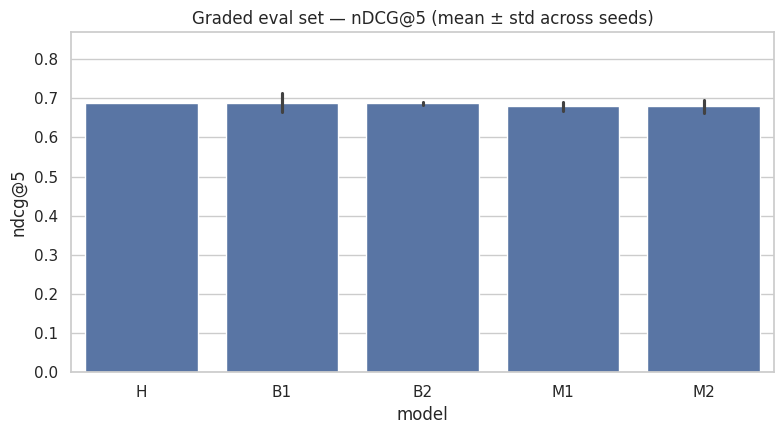

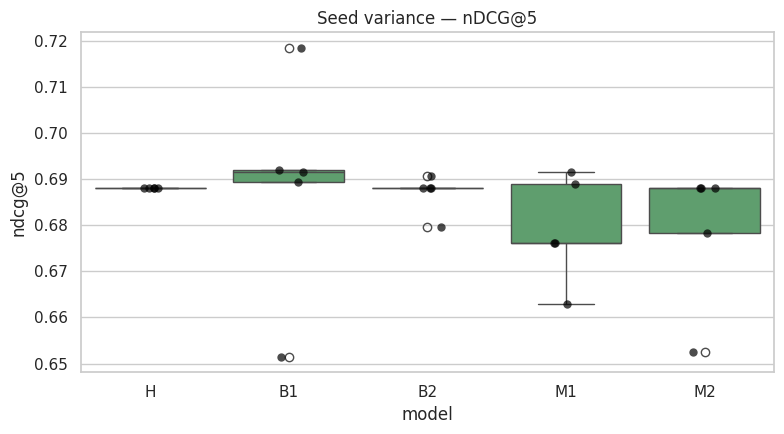

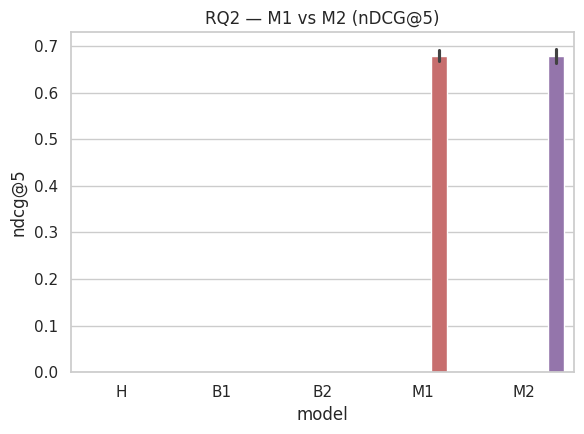

Figures → /home/mytam/EDA-insights/paper-2026/reports/phase4a/figures


In [17]:
plot_df = results_df.copy()
plot_df["model"] = pd.Categorical(plot_df["model"], order, ordered=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=plot_df, x="model", y="ndcg@5", errorbar="sd", ax=ax, color="#4C72B0")
ax.set_title("Graded eval set — nDCG@5 (mean ± std across seeds)")
ax.set_ylim(0, min(1.05, plot_df["ndcg@5"].max() + 0.15))
fig.tight_layout(); fig.savefig(FIG_DIR / "fig1_model_comparison_ndcg5.png", dpi=200); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=plot_df, x="model", y="ndcg@5", ax=ax, color="#55A868")
sns.stripplot(data=plot_df, x="model", y="ndcg@5", ax=ax, color="black", size=6, alpha=0.7)
ax.set_title("Seed variance — nDCG@5")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig2_seed_variance.png", dpi=200); plt.show()

abl = plot_df[plot_df["model"].isin(["M1", "M2"])]
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(data=abl, x="model", y="ndcg@5", hue="model", errorbar="sd", ax=ax, legend=False)
ax.set_title("RQ2 — M1 vs M2 (nDCG@5)")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig3_m1_vs_m2.png", dpi=200); plt.show()
print("Figures →", FIG_DIR)


## 17. Research Interpretation (bắt buộc điền sau Run All)

### RQ1 — LTR có cải thiện ranking trên graded set?

Dùng **seed-level CI** (`confidence_interval_seed_level.csv`), không dùng job-bootstrap 1 seed làm claim chính.

| So sánh | Δ nDCG@5 | 95% CI (seed) | CI loại 0? | Kết luận |
|---|---|---|---|---|
| B1 − H | | | | ablation |
| B2 − B1 | | | | soft vs hard |
| M1 − B2 | | | | |
| M1 − H | | | | |

Ổn định qua seeds? (std / boxplot)

### RQ2 — skill-gap

| | M1 QualSens | M2 QualSens |
|---|---|---|
| skill | | |
| exp | | |
| domain | | |

Nếu M2 ↑ NDCG nhưng QualSens không ↑: **skill-gap cải thiện ranking score nhưng chưa chứng minh phản ánh năng lực tốt hơn.**

### Giới hạn

1. Không hiring outcome — `y_prob` = weak relevance; gold ≠ GT chuyên gia.
2. LF phụ thuộc cùng 5 feature — không claim nguồn nhãn ngoài feature.
3. B1 target cắt từ H — không overclaim learned weighting.
4. Gold map 0–3, 1 annotator, ~12 JD → CI rộng / power thấp.
5. RankNet = hàm xếp hạng, không phải bộ trọng số tối ưu.
6. QualSens = perturbation feature bảng, không phải thử nghiệm tuyển dụng thật.
7. Job-disjoint cho phép CV overlap giữa split — không claim generalization sang ứng viên hoàn toàn mới.
8. Seed-level CI chỉ có 5 điểm — trung thực với variance train, nhưng interval rộng.
9. Một phần cặp gold nằm ngoài subsample 70 CV/JD nhưng vẫn cùng TF–IDF space (đã assert overlap khớp tuyệt đối).

### Reviewer checklist

- [x] Job-disjoint + gold hold-out
- [x] LF fit train-only
- [x] HP/early-stop theo val `L_rank`
- [x] B2 = soft BCEWithLogits
- [x] Shared TF–IDF adapter train/gold + overlap assert
- [x] Multi-seed mean±std
- [x] **Primary CI = seed-level paired deltas** (không neo 1 seed)
- [x] Bootstrap job-within-seed chỉ diagnostic
- [x] Có B2_vs_B1 trong bảng so sánh (soft vs hard)
- [x] λ chọn theo val pair-loss thuần
- [x] Interpretation không vượt evidence


In [18]:
print("Primary CI artifact:", OUT_DIR / "confidence_interval_seed_level.csv")
print("Artifacts:")
for p in sorted(OUT_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(ROOT))
print("Done.")


Primary CI artifact: /home/mytam/EDA-insights/paper-2026/reports/phase4a/confidence_interval_seed_level.csv
Artifacts:
 - reports/phase4a/b1_weights_by_seed.csv
 - reports/phase4a/checkpoints/m1_seed42.pt
 - reports/phase4a/checkpoints/m1_seed52.pt
 - reports/phase4a/checkpoints/m1_seed62.pt
 - reports/phase4a/checkpoints/m1_seed72.pt
 - reports/phase4a/checkpoints/m1_seed82.pt
 - reports/phase4a/checkpoints/m2_seed42.pt
 - reports/phase4a/checkpoints/m2_seed52.pt
 - reports/phase4a/checkpoints/m2_seed62.pt
 - reports/phase4a/checkpoints/m2_seed72.pt
 - reports/phase4a/checkpoints/m2_seed82.pt
 - reports/phase4a/confidence_interval.csv
 - reports/phase4a/confidence_interval_job_within_seed.csv
 - reports/phase4a/confidence_interval_seed_level.csv
 - reports/phase4a/figures/fig1_model_comparison_ndcg5.png
 - reports/phase4a/figures/fig2_seed_variance.png
 - reports/phase4a/figures/fig3_m1_vs_m2.png
 - reports/phase4a/results_all_runs.csv
 - reports/phase4a/results_summary_mean_std.csv
 